Exercise 3.7.2 Consider the points P(5, 10) and Q(10, 5) in R2. (a) Use Python to create 50 points
equally divided into two clusters in R2, first one centered at P, and the second one centered at Q.
Make the distances of the points from the centers normally distributed with a mean 0 and standard
deviation 2. (b) Use the random.sample function to select 20 integers from the set of integers from 1
to 50. Use these numbers as indices to select 20 points from the total of 50 points. Plot these points
using red circular markers. Plot the rest of the points using blue square markers. (d) Compute in your
program, out of the 20 points selected, how many are closer to point P than point Q

Number of points close to P:  7


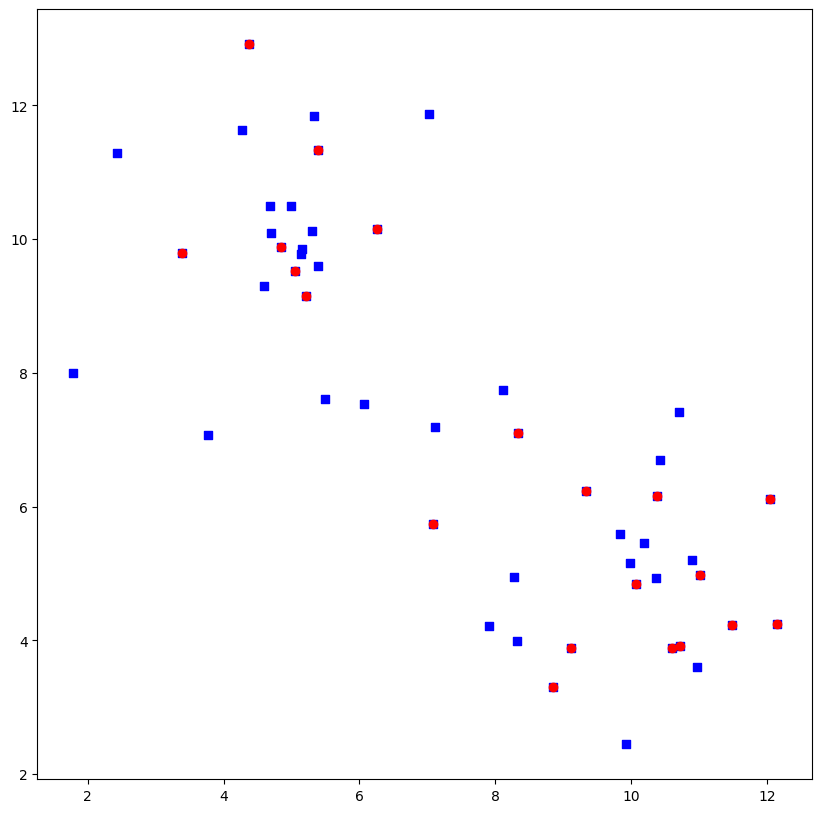

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
N  = 25 #divided into 2 portions
ran = np.random.normal(0, 2, 2*N) #make random normal  gausian distubution of values
valu = 2*np.pi*np.random.rand(2*N) #make random values for pi values

x = np.ones([2*N, 2])

x[0:N,0] = 5 + ran[0:N]*np.cos(valu[0:N])
x[0:N,1] = 10 + ran[0:N]*np.sin(valu[0:N])
x[N:2*N,0] = 10 + ran[N:2*N]*np.cos(valu[N:2*N])
x[N:2*N,1] = 5 + ran[N:2*N]*np.sin(valu[N:2*N])

plt.figure(figsize=(10,10))
plt.scatter(x[:,0],x[:,1], c='b', marker='s')

b = range(1,51)
sb = random.sample(b, 20)
p_total = 0
for i in range(len(sb)):
     plt.scatter(x[sb[i] - 1, 0], x[sb[i] - 1, 1],c='r', marker='o' )
     dist_x_p = 5 -  x[sb[i] - 1, 0]
     dist_y_p = 10 -  x[sb[i] - 1, 1]
     abs_p_dist = math.sqrt(dist_x_p* dist_x_p + dist_y_p * dist_y_p)
     dist_x_q = 10 -  x[sb[i] - 1, 0]
     dist_y_q = 5 -  x[sb[i] - 1, 1]
     abs_q_dist = math.sqrt(dist_x_q* dist_x_q + dist_y_q * dist_y_q)
     if (abs_p_dist < abs_q_dist):
        p_total += 1

print("Number of points close to P: ", p_total)

Exercise 4.1.2 Consider two cubic clusters of points in R3. The first one is uniformly distributed in
[14, 20] × [0, 6] × [0, 6] and the second in [0, 6] × [14, 20] × [14, 20]. Design a basic perceptron to
separate the two clusters of points.
(a) Find the equation of the ideal separating plane.
(c) From part (a) deduce the ideal parameter values.
(d) Simulate a total of 4000 points in the two clusters using Python.
(e) Use M = 100 points to train the basic perceptron.
(f) Use another 1000 points to find the error rate.
(g) If the error rate is smaller than 0.1 stop. Otherwise increase M, and repeat parts (e) and (f).

In [233]:
import numpy as np
import matplotlib.pyplot as plt
import random

#initialization

N = 2000
M = 100
x = np.zeros((2*N, 3))
t = np.zeros((2*N,1))

#data generation


x[0:N, 0] = 14 + 6 * np.random.rand(1,N)
x[0:N, 1] = 6 * np.random.rand(1,N)
x[0:N, 2] = 6 * np.random.rand(1,N)
t[0:N] = 0

x[N:2*N, 0] = 6 * np.random.rand(1,N)
x[N:2*N, 1] = 14 + 6 * np.random.rand(1,N)
x[N:2*N, 2] = 14 + 6 * np.random.rand(1,N)
t[N:2*N] = 1


## parameter initalization

w1 = 0.5 - np.random.rand()
w2 = 0.5 - np.random.rand()
w3 = 0.5 - np.random.rand()
b = 0.5 - np.random.rand()

a = range(0,2*N)
sp = random.sample(a, M +1000)

##training
for i in range(0, M):
    y = b + w1*x[sp[i], 0] + w2*x[sp[i],1] + w3*x[sp[i],2]
    if y < 0:
        y = 0
    else:
        y = 1
    e = t[sp[i]] - y
    w1 = w1 + e*x[sp[i], 0]
    w2 = w2 + e*x[sp[i], 1]
    w3 = w3 + e*x[sp[i], 2]
    b = b + e

## testing
er = 0
for i in range(M, M + 1000):
    y = b + w1*x[sp[i], 0] + w2*x[sp[i],1] + w3*x[sp[i],2]
    if y < 0 :
        y = 0
    else:
        y = 1

    e = abs(t[sp[i]] - y)
    er = er + e

er = er/1000

print(er)








[0.001]


(b) Modify the Python listing 4.2.1 to simulate the clusters of points, train, and test a neural
network that separates the clusters. Use the same probability distribution and create a total of 4000
points, but use a standard deviation of 2 for the distance from the center of the clusters. Use 1000
points for training and another 1000 for testing. Plot the points and the separating lines obtained using
training

0.006


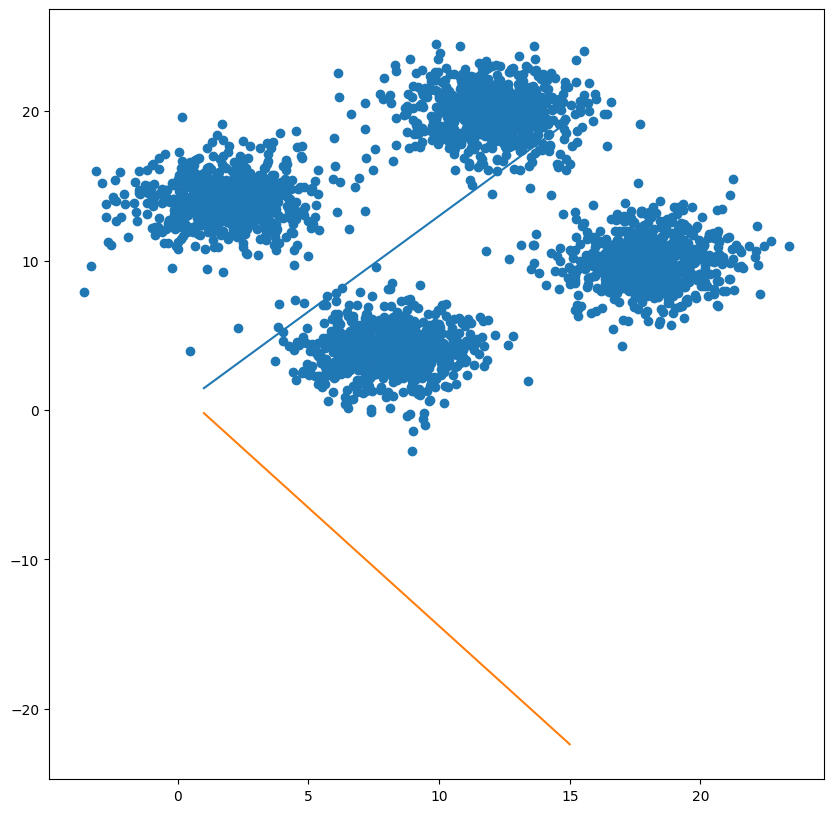

In [211]:
import numpy as np
import random
import matplotlib.pyplot as plt

N = 1000
M = 1000

p = [ 8, 4, 18, 10, 12, 20, 2, 14]

x = np.zeros((4*N, 2))
t = np.zeros((4*N,2))

r = np.random.normal(0, 2, 4*N)
the = 2*np.pi*np.random.rand(4*N)

#group 1 y1 = 0 y2 = 0
x[0:N,0] = p[0] + r[0:N]*np.cos(the[0:N])
x[0:N,1] = p[1] + r[0:N]*np.sin(the[0:N])
t[0:N,0] = 0
t[0:N,1] = 0

#group 2 y1 = 0 y2 = 1
x[N:2*N,0] = p[2] + r[N:2*N]*np.cos(the[N:2*N])
x[N:2*N,1] = p[3] + r[N:2*N]*np.sin(the[N:2*N])
t[N:2*N,0] = 0
t[N:2*N,1] = 1

#group 3 y1 = 1 y2 = 1
x[2*N:3*N,0] = p[4] + r[2*N:3*N]*np.cos(the[2*N:3*N])
x[2*N:3*N,1] = p[5] + r[2*N:3*N]*np.sin(the[2*N:3*N])
t[2*N:3*N,0] = 1
t[2*N:3*N,1] = 1


#group 4 y1 = 1 y2 = 0
x[3*N:4*N,0] = p[6] + r[3*N:4*N]*np.cos(the[3*N:4*N])
x[3*N:4*N,1] = p[7] + r[3*N:4*N]*np.sin(the[3*N:4*N])
t[3*N:4*N,0] = 1
t[3*N:4*N,1] = 0

plt.figure(figsize=(10,10))
plt.scatter(x[:,0], x[:,1])


w11 = 0.5 - np.random.rand()
w12 = 0.5 - np.random.rand()
b1 = 0.5 - np.random.rand()

w21 = 0.5 - np.random.rand()
w22 = 0.5 - np.random.rand()
b2 = 0.5 - np.random.rand()


a = range(0,4*N)

sp=random.sample(a, M+1000)

for i in range(0,M):
    y1 = b1 + w11*x[sp[i], 0] + w12*x[sp[i], 1]
    if y1 < 0:
        y1 = 0
    else:
        y1 = 1
    e = t[sp[i], 0] - y1

    w11 = w11 + e*x[sp[i], 0]
    w12 = w12 + e*x[sp[i], 1]
    b1 = b1 + e

for i in range(0,M):
    y2 = b2 + w21*x[sp[i], 0] + w22*x[sp[i], 1]
    if y2 < 0:
        y2 = 0
    else:
        y2 = 1
    e = t[sp[i], 1] - y2

    w21 = w21 + e*x[sp[i], 0]
    w22 = w22 + e*x[sp[i], 1]
    b2 = b2 + e


er = 0
for i in range(M, M + 1000):
    y1 = b1 + w11*x[sp[i], 0] + w12*x[sp[i], 1]
    if y1 < 0:
        y1 = 0
    else:
        y1 = 1
    e1= abs(t[sp[i], 0] - y1)

    y2 = b2 + w21*x[sp[i], 0] + w22*x[sp[i], 1]
    if y2 < 0:
        y2 = 0
    else:
        y2 = 1
    e2 = abs(t[sp[i], 0] - y1)
    if (e1 == 1 or e2 ==1):
        er = er+ 1
er = er/1000
print(er)

ii = np.linspace(1,15,15)
plt.plot(ii, (-b1-w11 * ii) / w12)
plt.plot(ii, (-b1-w21 * ii) / w22)